In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## ST: Setup of global variables a data paths

In [2]:
sns.set_palette(sns.color_palette("colorblind"))
sns.set_style("ticks", {'axes.grid': True})
sns.set_style("whitegrid", {"grid.color": ".6", "grid.linestyle": ":"})
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 20,
    'figure.figsize': (5, 3),
    "text.usetex": True,
    # The following line is needed to use the libertine font, but in some systems it may not work
    #"text.latex.preamble": r"\usepackage{libertine} \usepackage[libertine]{newtxmath} ",
})

In [3]:
sns.color_palette()

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
BASE_FOLDER = "../see-data"

### RQ1: Choice of the similarity measures to use

In [5]:
MODELS_RQ1 = ["veneres/monobert"]
SIM_TYPES = ["max", "mean", "mean_centroid", "amax"]
DATASET_RQ1 = "msmarco-train-sample"
SUBFOLDER_RQ1 = "rq1"
FILTER_LEVEL = ["0", "4", "8", "12"]

table1 = None

for model in MODELS_RQ1:
    for sim_type in SIM_TYPES:
        df = pd.read_csv(f"{BASE_FOLDER}/{SUBFOLDER_RQ1}/{DATASET_RQ1}/{model}/{sim_type}/stats.csv")
        df = df[df['exit_level'].isin(FILTER_LEVEL)]
        df = df.drop(columns=['delta_ndcg', 'ndcg'])
        df["model"] = model
        df["sim_type"] = sim_type
        table1 = pd.concat([table1, df]) if table1 is not None else df
table1 = table1.pivot_table(index=["sim_type"], columns=["exit_level"], values="recall")
table1.sort_index(axis=1, level=1, inplace=True)

In [6]:
table1 = table1[['0', '4', '8', '12']]


In [7]:
table1 = table1.reindex(SIM_TYPES, axis=0)
table1 = table1.style.format(precision=2)
print(table1.to_latex())

\begin{tabular}{lrrrr}
exit_level & 0 & 4 & 8 & 12 \\
sim_type &  &  &  &  \\
max & 0.28 & 0.45 & 0.45 & 0.69 \\
mean & 0.33 & 0.30 & 0.21 & 0.37 \\
mean_centroid & 0.36 & 0.33 & 0.27 & 0.68 \\
amax & 0.67 & 0.73 & 0.72 & 0.85 \\
\end{tabular}



### RQ2: Early Exit Strategies and position

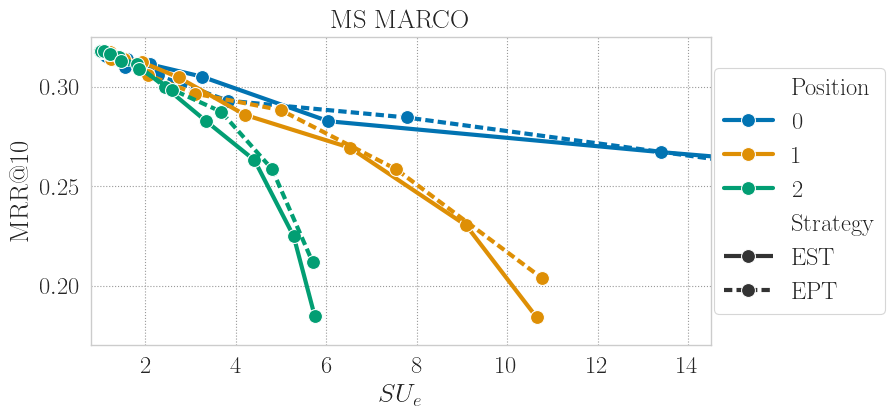

In [8]:
MODELS = ["veneres/monobert"]
MODEL_DISPLAY_NAME = {
    "veneres/monobert": "MonoBERT"
}
MODE_DICTIONARY = {
    "STATIC_THRESHOLD": "EST",
    "PROXIMITY_STATIC": "EPT",
}

with sns.plotting_context('paper', font_scale=2, ):
    f, ax = plt.subplots(1, 1, sharey=True, figsize=(8, 4))
    for fig_idx, model in enumerate(MODELS):
        #ax = axs[fig_idx]
        marksize = 10
        linewidth = 3
        dataset_df = pd.read_csv(f"../see-data/rq2/stats.csv")
        modes = dataset_df['mode'].unique()
        nmodes = len(modes)
        list_for_df = []
        for mode in modes:
            # We are going to plot the speedup vs ndcg for each model and mode
            # In each row we will have a different mode
            # In each column we will have a different model
            current_df = dataset_df[(dataset_df['model'] == model) & (dataset_df['mode'] == mode)]
            # For ech subplot we will plot the curve for the different exit positions and parameters
            for exit_pos in current_df['exit_position'].unique():
                exit_df = current_df[current_df['exit_position'] == exit_pos]
                for param in exit_df['param'].unique():
                    param_df = exit_df[exit_df['param'] == param]
                    config_speedup = param_df['base_cost'].sum() / param_df['cost'].sum()
                    config_ndcg = param_df['exit_mrr'].mean()
                    list_for_df.append([exit_pos, param, config_ndcg, config_speedup, MODE_DICTIONARY[mode]])

        df = pd.DataFrame(list_for_df, columns=['Position', 'param', 'ndcg', 'speedup', "Strategy"])
        lplot = sns.lineplot(data=df, x='speedup', y='ndcg', hue='Position', style="Strategy",
                             dashes=[(1, 0), (2, 1)],
                             palette=sns.color_palette()[:3], linewidth=linewidth, marker='o', markersize=marksize,
                             ax=ax, legend='auto')
        lplot.set(xlabel='$SU_e$')
        lplot.set(ylabel=r'MRR@10')
        lplot.set_title("MS MARCO")
        sns.move_legend(lplot, "center right", bbox_to_anchor=(1.3, 0.5), ncol=1)

        min_y = df['ndcg'].min() - 0.01
        max_y = df['ndcg'].max() + 0.01

        lplot.set_xlim((0.8, 14.5))

        plt.savefig(f'images/level_mode_comparison.pdf', bbox_inches='tight')

# RQ3 comparison with SOTA

In [10]:
from collections import namedtuple
from pathlib import Path

Fig3Row = namedtuple("Fig3Row", ["dataset", "model", "value", "speedup", "speedup_type"])

DATASET_DISPLAY_NAME = {
    "msmarco-passage/trec-dl-2019/judged/": "trec-dl-2019",
    "msmarco-passage/dev/small/": "dev",
    "asnq": "ASNQ",
}
MODEL_DISPLAY_NAME = {
    "eemb": "eeMB",
    "eemb_plus": "eeMB$_{+}$",
    "see": "SEE-MonoBERT",
}
fig_rows = []

for dataset in ["msmarco-passage/dev/small/", "msmarco-passage/trec-dl-2019/judged/", "asnq"]:
    # Compute reference stats
    full_res = pd.read_csv(Path(BASE_FOLDER) / f"rq3/{dataset}/full.csv")
    full_res = full_res.groupby("test_id").agg({"scoreddoc_counter": "sum",
                                                "query_time": "sum",
                                                "estimated_cost": "sum",
                                                "value": "mean"
                                                })
    full_estimated_cost = full_res["estimated_cost"].mean()
    full_real_cost = full_res["query_time"].mean()

    dataset_display_name = DATASET_DISPLAY_NAME[dataset]

    for ee_param in [0.2, 0.3, 0.4, 0.5, 0.9]:
        aux = pd.read_csv(Path(BASE_FOLDER) / f"rq3/{dataset}/see_{ee_param}.csv")
        aux = aux.groupby("test_id").agg({"scoreddoc_counter": "sum",
                                          "query_time": "sum",
                                          "estimated_cost": "sum",
                                          "value": "mean"
                                          })
        estimated_cost = aux["estimated_cost"].mean()
        real_cost = aux["query_time"].mean()
        speedup_estimated = full_estimated_cost / estimated_cost

        fig_rows.append(Fig3Row(dataset_display_name, MODEL_DISPLAY_NAME["see"], aux["value"].mean(), speedup_estimated,
                                "estimated"))
        speedup_real = full_real_cost / real_cost
        fig_rows.append(
            Fig3Row(dataset_display_name, MODEL_DISPLAY_NAME["see"], aux["value"].mean(), speedup_real, "real"))

    for model in ["eemb", "eemb_plus"]:
        for ee_param in [0.7, 0.8, 0.9, 0.95, 1]:
            aux = pd.read_csv(Path(BASE_FOLDER) / f"rq3/{dataset}/{model}_{ee_param}.csv")
            aux = aux.groupby("test_id").agg({"scoreddoc_counter": "sum",
                                              "query_time": "sum",
                                              "estimated_cost": "sum",
                                              "value": "mean"
                                              })
            estimated_cost = aux["estimated_cost"].mean()
            real_cost = aux["query_time"].mean()
            if model == "eemb_plus":
                speedup_estimated = full_estimated_cost / estimated_cost
                fig_rows.append(
                    Fig3Row(dataset_display_name, MODEL_DISPLAY_NAME[model], aux["value"].mean(), speedup_estimated,
                            "estimated"))
            speedup_real = full_real_cost / real_cost
            fig_rows.append(
                Fig3Row(dataset_display_name, MODEL_DISPLAY_NAME[model], aux["value"].mean(), speedup_real, "real"))



In [11]:
df_fig3 = pd.DataFrame(fig_rows)

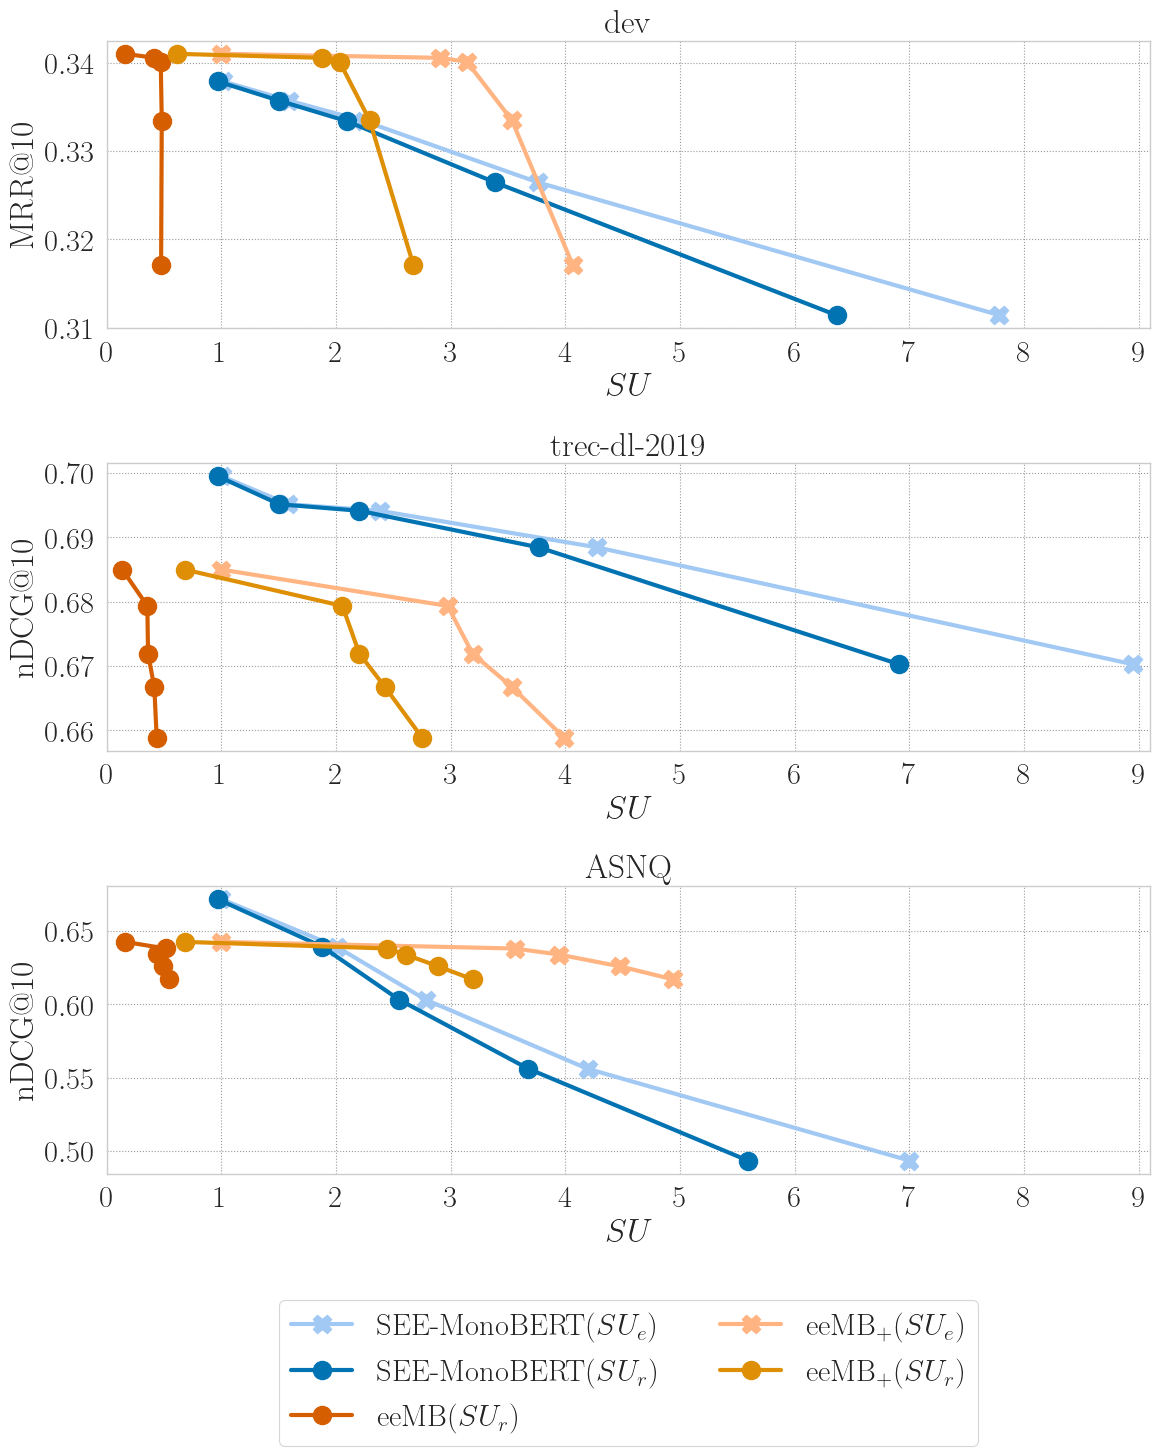

In [12]:
MODEL_FIG_3 = "veneres/monobert"
MODEL_FIG_3_ASNQ = "veneres/monobert-asnq"
MODE_DICTIONARY = {
    "STATIC_THRESHOLD": "EST",
    "PROXIMITY_STATIC": "EPT",

}
FIX_POS_CONF = 1
MARKERSIZE = 7
LINEWIDTH = 6
PLOT_PALETTE = sns.color_palette(None, 5)
PLOT_PALETTE.insert(1, 'black')

DATASET_TO_PLOT = ["dev", 'trec-dl-2019', "ASNQ"]
list_for_df = []
marksize = 13
linewidth = 3
df_fig3 = df_fig3.rename(columns={"model": "Model",
                                  "speedup_type": "Speedup Type",
                                  })
df_fig3 = df_fig3.replace("real", "$SU_{r}$")
df_fig3 = df_fig3.replace("estimated", "$SU_{e}$")

pastel_colors = sns.color_palette("pastel", 4)
standard_colors = sns.color_palette(None, 4)

color_map = {
    ("eeMB", "$SU_{r}$"): standard_colors[3],
    ("eeMB$_{+}$", "$SU_{r}$"): standard_colors[1],
    ("eeMB$_{+}$", "$SU_{e}$"): pastel_colors[1],
    ("SEE-MonoBERT", "$SU_{r}$"): standard_colors[0],
    ("SEE-MonoBERT", "$SU_{e}$"): pastel_colors[0],
}

marker_map = {
    "$SU_{r}$": "o",
    "$SU_{e}$": "X",
}
with sns.plotting_context('paper', font_scale=2.5):
    f, axs = plt.subplots(3, 1, sharey=False, figsize=(12, 15), tight_layout=True)
    for fig_idx, dataset in enumerate(DATASET_TO_PLOT):
        ax = axs[fig_idx]

        plot_colors = [color_map[(row["Model"], row["Speedup Type"])] for row_idx, row in
                       df_fig3[df_fig3["dataset"] == dataset].iterrows()]
        for model in df_fig3["Model"].unique():
            for speedup_type in df_fig3["Speedup Type"].unique():
                current_df = df_fig3[(df_fig3["dataset"] == dataset) & (df_fig3["Model"] == model) & (
                        df_fig3["Speedup Type"] == speedup_type)]
                if len(current_df) == 0:
                    continue
                ax.plot(current_df["speedup"], current_df["value"], label=f"{model}({speedup_type})",
                        marker=marker_map[speedup_type], markersize=marksize, linewidth=linewidth,
                        color=color_map[(model, speedup_type)])
        #axis.set_ylim((miny, maxy))
        #axis.set_yticks(np.arange(miny, maxy, step_y[i]))
        ax.set_xlim((0.2, 9.1))
        ax.set_xticks([0] + (np.arange(1, 9.1, 1).tolist()))
        if fig_idx == 0:
            ax.set_ylabel("MRR@10")
        else:
            ax.set_ylabel("nDCG@10")
        ax.set_xlabel("$SU$")
        ax.set_title(f"{dataset}")
        if fig_idx == 2:
            ax.legend(loc='lower center', bbox_to_anchor=(0.5, -1), ncol=2)
        plt.savefig(f'images/competitor_comparison.pdf')

## Table 2

In [13]:
from scipy.stats import ttest_rel
from collections import namedtuple, defaultdict
from pathlib import Path

DATASETS_SETS = {
    "msmarco": ["beir/msmarco/test"],
    "trec-covid": ["beir/trec-covid"],
    "nfcorpus": ["beir/nfcorpus/test"],
    "nq": ["beir/nq"],
    "hotpotqa": ["beir/hotpotqa/test"],
    "fiqa": ["beir/fiqa/test"],
    "arguana": ["beir/arguana"],
    "touche": ["beir/webis-touche2020/v2"],
    "cqadupstack": ["beir/cqadupstack/android",
                    "beir/cqadupstack/english",
                    "beir/cqadupstack/gaming",
                    "beir/cqadupstack/gis",
                    "beir/cqadupstack/mathematica",
                    "beir/cqadupstack/physics",
                    "beir/cqadupstack/programmers",
                    "beir/cqadupstack/stats",
                    "beir/cqadupstack/tex",
                    "beir/cqadupstack/unix",
                    "beir/cqadupstack/webmasters",
                    "beir/cqadupstack/wordpress",
                    ],
    "quora": ["beir/quora/test"],
    "dbpedia": ["beir/dbpedia-entity/test"],
    "scidocs": ["beir/scidocs"],
    "fever": ["beir/fever/test"],
    "scifact": ["beir/scifact/test"],
    "climate-fever": ["beir/climate-fever"],

}
MODELS = ["veneres/monobert"]

DATASET_DISPLAY_NAME = {
    "arguana": "ArguANA\cite{wachsmuth_retrieval_2018}",
    "climate-fever": "Climate-FEVER~\cite{leippold_climate-fever_2020}",
    "cqadupstack": "CQADupStack~\cite{hoogeveen_cqadupstack_2015}",
    "dbpedia": "DBPedia~\cite{hasibi_dbpedia-entity_2017}",
    "fever": "FEVER~\cite{thorne_fever_2018}",
    "fiqa": "FIQA~\cite{maia_www18_2018}",
    "hotpotqa": "HotpotQA~\cite{yang_hotpotqa_2018}",
    "msmarco": "MS MARCO~\cite{bajaj_ms_2018}",
    "nfcorpus": "NFCorpus~\cite{boteva_full-text_2016}",
    "nq": "Natural Questions~\cite{kwiatkowski_natural_2019}",
    "quora": "Quora",
    "scidocs": "SCIDOCS~\cite{cohan_specter_2020}",
    "scifact": "SciFact~\cite{wadden_fact_2020}",
    "trec-covid": "TREC-COVID~\cite{voorhees_trec-covid_2021}",
    "touche": "Touché-2020~\cite{bondarenko2020overview}",

}
MODEL_NICKNAME = {
    "veneres/monobert": "monobert",
    "eemb_plus": "eemb",
    "veneres/monobert_see": "see",
    "veneres/monobert_see_quick": "see_quick",
    "veneres/monobert_lt_fixed_10": "lt_10",
    "veneres/monobert_lt_fixed_100": "lt_100",
    "veneres/monobert_lt_fixed_200": "lt_200",
    "veneres/monobert_lt_fixed_500": "lt_500",
}

P_VALUE_THRESHOLD = 0.01

MODEL = "veneres/monobert"

EE_STRATEGIES = ["eemb_plus",
                 "veneres/monobert_see"]

LIST_TRUNC_K = [100, 500, 1000]

column_names = []
for k in LIST_TRUNC_K:
    column_names.append(f"{MODEL_NICKNAME[MODEL]}_{k}")
    for ee_strategy in EE_STRATEGIES:
        column_names.append(f"{MODEL_NICKNAME[ee_strategy]}_{k}")

Table4Row = namedtuple("Table4Row", ["dataset"] + column_names)

BONFERRONI_CORRECTED_MONOBERT = P_VALUE_THRESHOLD / len(EE_STRATEGIES)

table_rows = []

sum_ndcg_per_model = defaultdict(int)
sum_exe_time_per_model = defaultdict(int)

for dataset_key, dataset_set in DATASETS_SETS.items():

    dataset_dict_res = {}
    for list_trunc_k in LIST_TRUNC_K:
        list_trunc_suffix = f"_{list_trunc_k}"
        see_lower_effectiveness = False
        # Compute reference stats
        full_res = None
        for dataset in dataset_set:

            to_concat_full_res = pd.read_csv(Path(BASE_FOLDER) / f"rq4/{dataset}/{MODEL}_full{list_trunc_suffix}.csv")

            if full_res is None:
                full_res = to_concat_full_res
            else:
                full_res = pd.concat([full_res, to_concat_full_res])
            full_res["dataset"] = dataset

        full_real_cost = full_res["query_time"].sum()
        full_estimated_cost = full_res["estimated_cost"].sum()
        avg_query_time = full_res["query_time"].mean()
        avg_ndcg = full_res['value'].mean()


        avg_ndcg_to_display = avg_ndcg * 100

        sum_ndcg_per_model[f"{MODEL}_{list_trunc_k}"] += avg_ndcg
        sum_exe_time_per_model[f"{MODEL}_{list_trunc_k}"] += avg_query_time

        dataset_dict_res[
            f"{MODEL_NICKNAME[MODEL]}_{list_trunc_k}"] = f"{avg_ndcg_to_display:0.1f} ({(avg_query_time / 1e9):0.2f})"

        ee_ndcg_for_comparison = {}
        ee_speedup_real_for_comparison = {}
        lower_effectiveness_for_comparison = {}
        # Compute the results for the ee strategies model
        for ee_strategy in EE_STRATEGIES:
            ee_res = None
            for dataset in dataset_set:
                aux = pd.read_csv(Path(BASE_FOLDER) / f"rq4/{dataset}/{ee_strategy}{list_trunc_suffix}.csv")
                if ee_res is None:
                    ee_res = aux
                else:
                    ee_res = pd.concat([ee_res, aux])
                ee_res["dataset"] = dataset

            real_cost = ee_res["query_time"].sum()
            estimated_cost = ee_res["estimated_cost"].sum()
            ee_speedup_real = full_real_cost / real_cost
            ee_speedup_real_for_comparison[f"{MODEL_NICKNAME[ee_strategy]}_{list_trunc_k}"] = ee_speedup_real

            speedup_estimated = full_estimated_cost / estimated_cost
            avg_query_time = ee_res["query_time"].mean()

            # We double check the speedup, the difference between the estimated and real speedup should be very small for SEE (~0.5-0.6),
            # while for eemb given the rebatching after each transformer block it can be larger (~1.5).
            # We set a lower bound to be more conservative and better check the differences
            if abs(speedup_estimated - ee_speedup_real) > 0.5 and not ee_strategy == "eemb_plus":
                print(
                    f"Large difference in speedup for {ee_strategy} in dataset {dataset_key} with {list_trunc_k=}. {speedup_estimated=} {ee_speedup_real=}")

            elif ee_strategy == "eemb_plus" and abs(speedup_estimated - ee_speedup_real) > 1:
                print(
                    f"Large difference in speedup for {ee_strategy} in dataset {dataset_key} with {list_trunc_k=}. {speedup_estimated=} {ee_speedup_real=}")

            statistic, p_value = ttest_rel(full_res.sort_values(by=["dataset", "query_id"])["value"].values,
                                           ee_res.sort_values(by=["dataset", "query_id"])["value"].values)

            ee_ndcg = ee_res["value"].mean() * 100
            ee_ndcg_for_comparison[f"{MODEL_NICKNAME[ee_strategy]}_{list_trunc_k}"] = ee_ndcg

            sum_ndcg_per_model[f"{ee_strategy}_{list_trunc_k}"] += ee_res["value"].mean()
            sum_exe_time_per_model[f"{ee_strategy}_{list_trunc_k}"] += avg_query_time

            ndcg_are_different = p_value < BONFERRONI_CORRECTED_MONOBERT

            low_effect = False
            if ndcg_are_different:
                if ee_res["value"].mean() > full_res["value"].mean():
                    ndcg_text = fr'$\uparrow${ee_ndcg:0.1f}'
                else:
                    ndcg_text = fr'$\downarrow${ee_ndcg:0.1f}'
                    low_effect = True
            else:
                ndcg_text = fr'{ee_ndcg:0.1f}'

            lower_effectiveness_for_comparison[f"{MODEL_NICKNAME[ee_strategy]}_{list_trunc_k}"] = low_effect

            #entry_label = f"{ndcg_text} ({(avg_query_time / 1e9):0.2f}/{ee_speedup_real:0.1f}x)" # Another way to display the data
            entry_label = fr"{ndcg_text} ({ee_speedup_real:0.1f}$\times$)"

            dataset_dict_res[f"{MODEL_NICKNAME[ee_strategy]}_{list_trunc_k}"] = entry_label

        # Find the best tradeoff and highlight the entry

        if len(EE_STRATEGIES) > 2:
            raise ValueError("This code is not prepared for more than one EE strategy")

        ee_strategy_1 = f"{MODEL_NICKNAME[EE_STRATEGIES[0]]}_{list_trunc_k}"
        ee_strategy_2 = f"{MODEL_NICKNAME[EE_STRATEGIES[1]]}_{list_trunc_k}"

        if lower_effectiveness_for_comparison[ee_strategy_1] and lower_effectiveness_for_comparison[ee_strategy_2]:
            if ee_ndcg_for_comparison[ee_strategy_1] > ee_ndcg_for_comparison[ee_strategy_2]:
                dataset_dict_res[ee_strategy_1] = fr"\bfseries{dataset_dict_res[ee_strategy_1]}"
            else:
                dataset_dict_res[ee_strategy_2] = fr"\bfseries{dataset_dict_res[ee_strategy_2]}"
        elif not lower_effectiveness_for_comparison[ee_strategy_1] and lower_effectiveness_for_comparison[ee_strategy_2]:
            dataset_dict_res[ee_strategy_1] = fr"\bfseries{dataset_dict_res[ee_strategy_1]}"
        elif lower_effectiveness_for_comparison[ee_strategy_1] and not lower_effectiveness_for_comparison[ee_strategy_2]:
            dataset_dict_res[ee_strategy_2] = fr"\bfseries{dataset_dict_res[ee_strategy_2]}"
        else:
            if ee_speedup_real_for_comparison[ee_strategy_1] > ee_speedup_real_for_comparison[ee_strategy_2]:
                dataset_dict_res[ee_strategy_1] = fr"\bfseries{dataset_dict_res[ee_strategy_1]}"
            else:
                dataset_dict_res[ee_strategy_2] = fr"\bfseries{dataset_dict_res[ee_strategy_2]}"


    dataset_display_name = DATASET_DISPLAY_NAME[dataset_key]
    table_rows.append(Table4Row(dataset=dataset_display_name, **dataset_dict_res))

avg_dict_res = {"dataset": "Average"}

for k in LIST_TRUNC_K:
    full_avg_ndcg = sum_ndcg_per_model[f"{MODEL}_{k}"] / len(DATASETS_SETS) * 100
    full_avg_cost = sum_exe_time_per_model[f"{MODEL}_{k}"] / len(DATASETS_SETS) / 1e9

    avg_dict_res[f"{MODEL_NICKNAME[MODEL]}_{k}"] = f"{full_avg_ndcg:0.1f} ({full_avg_cost:0.2f})"

    for ee_strategy in EE_STRATEGIES:
        ee_avg_ndcg = sum_ndcg_per_model[f"{ee_strategy}_{k}"] / len(DATASETS_SETS) * 100
        ee_avg_cost = sum_exe_time_per_model[f"{ee_strategy}_{k}"] / len(DATASETS_SETS) / 1e9
        ee_avg_speedup = sum_exe_time_per_model[f"{MODEL}_{k}"] / sum_exe_time_per_model[f"{ee_strategy}_{k}"]
        #avg_dict_res[f"{MODEL_NICKNAME[ee_strategy]}_{k}"] = f"{ee_avg_ndcg:0.1f} ({ee_avg_cost:0.2f}/{ee_avg_speedup:0.1f}x)" # Another way to display the data
        avg_dict_res[f"{MODEL_NICKNAME[ee_strategy]}_{k}"] = fr"{ee_avg_ndcg:0.1f} ({ee_avg_speedup:0.1f}$\times$)"
table_rows.append(Table4Row(**avg_dict_res))

Large difference in speedup for eemb_plus in dataset nfcorpus with list_trunc_k=100. speedup_estimated=3.45913914199784 ee_speedup_real=2.4487837391293454
Large difference in speedup for eemb_plus in dataset nfcorpus with list_trunc_k=500. speedup_estimated=3.822304269620373 ee_speedup_real=2.7098053124487667
Large difference in speedup for eemb_plus in dataset nfcorpus with list_trunc_k=1000. speedup_estimated=3.894804114263665 ee_speedup_real=2.611489442625629
Large difference in speedup for eemb_plus in dataset arguana with list_trunc_k=1000. speedup_estimated=3.4338076188522386 ee_speedup_real=2.3376228523441713
Large difference in speedup for eemb_plus in dataset quora with list_trunc_k=1000. speedup_estimated=3.739374334118706 ee_speedup_real=2.562958736919099
Large difference in speedup for eemb_plus in dataset scifact with list_trunc_k=1000. speedup_estimated=3.532760960636211 ee_speedup_real=2.3928226565616284
Large difference in speedup for eemb_plus in dataset climate-fever 

In [14]:
pd.DataFrame(table_rows)

,dataset,monobert_100,eemb_100,see_100,monobert_500,eemb_500,see_500,monobert_1000,eemb_1000,see_1000
0,MS MARCO~\cite{bajaj_ms_2018},69.9 (0.23),68.0 (1.3$\times$),\bfseries66.6 (1.7$\times$),68.7 (1.08),68.2 (1.8$\times$),\bfseries66.1 (2.7$\times$),68.1 (2.12),68.1 (2.0$\times$),\bfseries67.1 (3.1$\times$)
1,TREC-COVID~\cite{voorhees_trec-covid_2021},66.0 (0.22),64.9 (0.9$\times$),\bfseries65.9 (1.1$\times$),61.5 (1.07),62.9 (0.9$\times$),\bfseries61.4 (1.2$\times$),61.5 (2.13),59.9 (0.9$\times$),\bfseries61.5 (1.2$\times$)
2,NFCorpus~\cite{boteva_full-text_2016},34.1 (0.22),$\downarrow$30.2 (2.4$\times$),\bfseries33.4 (1.5$\times$),34.1 (1.06),$\downarrow$29.0 (2.7$\times$),\bfseries33.5 (2.6$\times$),34.0 (2.11),$\downarrow$28.5 (2.6$\times$),\bfseries33.6 (3.5$\times$)
3,Natural Questions~\cite{kwiatkowski_natural_2019},45.5 (0.21),\bfseries44.8 (1.5$\times$),$\downarrow$44.3 (1.4$\times$),47.1 (1.06),\bfseries46.4 (2.0$\times$),$\downarrow$45.7 (1.7$\times$),47.4 (2.12),\bfseries46.7 (2.1$\times$),$\downarrow$46.1 (1.8$\times$)
4,HotpotQA~\cite{yang_hotpotqa_2018},70.3 (0.21),\bfseries$\downarrow$69.3 (1.6$\times$),$\downarrow$68.9 (1.4$\times$),71.0 (1.06),\bfseries$\downarrow$70.0 (2.0$\times$),$\downarrow$69.7 (1.8$\times$),71.2 (2.11),\bfseries$\downarrow$70.1 (2.0$\times$),$\downarrow$69.9 (1.9$\times$)
5,FIQA~\cite{maia_www18_2018},36.0 (0.21),\bfseries$\downarrow$32.7 (1.5$\times$),$\downarrow$32.5 (1.6$\times$),35.9 (1.06),$\downarrow$32.2 (2.0$\times$),\bfseries$\downarrow$32.8 (2.2$\times$),36.2 (2.11),$\downarrow$32.4 (2.1$\times$),\bfseries$\downarrow$33.1 (2.5$\times$)
6,ArguANA\cite{wachsmuth_retrieval_2018},39.8 (0.21),$\downarrow$33.2 (1.7$\times$),\bfseries39.3 (1.0$\times$),39.9 (1.06),$\downarrow$32.5 (2.3$\times$),\bfseries$\downarrow$39.2 (1.1$\times$),39.8 (2.13),$\downarrow$32.4 (2.3$\times$),\bfseries39.1 (1.1$\times$)
7,Touché-2020~\cite{bondarenko2020overview},31.8 (0.23),33.3 (1.1$\times$),\bfseries32.7 (1.2$\times$),30.6 (1.07),32.6 (1.4$\times$),\bfseries31.5 (1.4$\times$),30.4 (2.13),\bfseries32.6 (1.6$\times$),31.0 (1.5$\times$)
8,CQADupStack~\cite{hoogeveen_cqadupstack_2015},33.5 (0.21),$\downarrow$29.7 (1.5$\times$),\bfseries$\downarrow$32.3 (1.5$\times$),33.5 (1.06),$\downarrow$29.2 (1.9$\times$),\bfseries$\downarrow$32.4 (1.9$\times$),33.5 (2.11),$\downarrow$29.1 (2.0$\times$),\bfseries$\downarrow$32.5 (2.2$\times$)
9,Quora,82.9 (0.21),$\downarrow$68.7 (1.8$\times$),\bfseries$\downarrow$81.1 (1.5$\times$),82.3 (1.06),$\downarrow$67.4 (2.4$\times$),\bfseries$\downarrow$80.7 (1.9$\times$),82.2 (2.11),$\downarrow$67.1 (2.6$\times$),\bfseries$\downarrow$80.7 (2.2$\times$)


In [15]:
table = str(pd.DataFrame(table_rows).to_latex(index=False))
table = table.replace("TREC-COVID", "\midrule\nTREC-COVID")
table = table.replace("Natural Questions", "\midrule\nNatural Questions")
table = table.replace("ArguANA", "\midrule\nArguANA")
table = table.replace("CQADupStack", "\midrule\nCQADupStack")
table = table.replace("DBPedia", "\midrule\nDBPedia")
table = table.replace("FEVER~\cite{thorne_fever_2018}", "\midrule\nFEVER~\cite{thorne_fever_2018}")
table = table.replace("Average", "\midrule\nAverage")
print(table)

\begin{tabular}{llllllllll}
\toprule
dataset & monobert_100 & eemb_100 & see_100 & monobert_500 & eemb_500 & see_500 & monobert_1000 & eemb_1000 & see_1000 \\
\midrule
MS MARCO~\cite{bajaj_ms_2018} & 69.9 (0.23) & 68.0 (1.3$\times$) & \bfseries66.6 (1.7$\times$) & 68.7 (1.08) & 68.2 (1.8$\times$) & \bfseries66.1 (2.7$\times$) & 68.1 (2.12) & 68.1 (2.0$\times$) & \bfseries67.1 (3.1$\times$) \\
\midrule
TREC-COVID~\cite{voorhees_trec-covid_2021} & 66.0 (0.22) & 64.9 (0.9$\times$) & \bfseries65.9 (1.1$\times$) & 61.5 (1.07) & 62.9 (0.9$\times$) & \bfseries61.4 (1.2$\times$) & 61.5 (2.13) & 59.9 (0.9$\times$) & \bfseries61.5 (1.2$\times$) \\
NFCorpus~\cite{boteva_full-text_2016} & 34.1 (0.22) & $\downarrow$30.2 (2.4$\times$) & \bfseries33.4 (1.5$\times$) & 34.1 (1.06) & $\downarrow$29.0 (2.7$\times$) & \bfseries33.5 (2.6$\times$) & 34.0 (2.11) & $\downarrow$28.5 (2.6$\times$) & \bfseries33.6 (3.5$\times$) \\
\midrule
Natural Questions~\cite{kwiatkowski_natural_2019} & 45.5 (0.21) & \bfseri

In [16]:
from scipy.stats import ttest_rel
from collections import namedtuple, defaultdict
from pathlib import Path
MODELS = ["veneres/monoelectra", "cross-encoder/ms-marco-MiniLM-L-12-v2",
          "naver/trecdl22-crossencoder-electra"]

Table5Row = namedtuple("Table4Row", ["dataset",
                                     "monoelectra",
                                     "see_monoelectra",
                                     "minilm",
                                     "see_minilm",
                                     "xelectra",
                                     "see_xelectra"
                                     ])

MODEL_NICKNAME = {
    "veneres/monobert": "monobert",
    "veneres/monoelectra": "monoelectra",
    "cross-encoder/ms-marco-MiniLM-L-12-v2": "minilm",
    "naver/trecdl22-crossencoder-electra": "xelectra",
}

P_VALUE_THRESHOLD = 0.01

table_rows = []

sum_ndcg_per_model = defaultdict(int)
sum_exe_time_per_model = defaultdict(int)
for dataset_key, dataset_set in DATASETS_SETS.items():
    dataset_dict_res = {}
    for model in MODELS:
        see_lower_effectiveness = False

        # Compute reference stats
        full_res = None
        for dataset in dataset_set:
            to_concat_full_res = pd.read_csv(Path(BASE_FOLDER) / f"rq5/{dataset}/{model}_full.csv")
            if full_res is None:
                full_res = to_concat_full_res
            else:
                full_res = pd.concat([full_res, to_concat_full_res])
            full_res["dataset"] = dataset

        avg_query_time = full_res["query_time"].mean()
        full_real_cost = full_res["query_time"].sum()
        full_estimated_cost = full_res["estimated_cost"].sum()

        full_ndcg = full_res['value'].mean() * 100

        sum_ndcg_per_model[model] += full_res['value'].mean()
        sum_exe_time_per_model[model] += avg_query_time

        dataset_dict_res[
            f"{MODEL_NICKNAME[model]}"] = f"{full_ndcg:0.1f} ({(avg_query_time / 1e9):0.2f})"

        see_res = None
        for dataset in dataset_set:
            aux = pd.read_csv(Path(BASE_FOLDER) / f"rq5/{dataset}/{model}_see.csv")
            if see_res is None:
                see_res = aux
            else:
                see_res = pd.concat([see_res, aux])
            see_res["dataset"] = dataset

        real_cost = see_res["query_time"].sum()
        estimated_cost = see_res["estimated_cost"].sum()
        see_speedup_real = full_real_cost / real_cost
        speedup_estimated = full_estimated_cost / estimated_cost

        # We double check the speedup
        if abs(speedup_estimated - see_speedup_real) > 0.5:
            print(
                f"Large difference in speedup for model {model} dataset {dataset_key}. {speedup_estimated=} {see_speedup_real=}")

        statistic, p_value = ttest_rel(full_res.sort_values(by=["dataset", "query_id"])["value"].values,
                                       see_res.sort_values(by=["dataset", "query_id"])["value"].values)

        see_ndcg = see_res["value"].mean() * 100
        avg_query_time = see_res["query_time"].mean()

        sum_ndcg_per_model[f"{model}_see"] += see_res["value"].mean()
        sum_exe_time_per_model[f"{model}_see"] += avg_query_time


        ndcg_are_different = p_value < P_VALUE_THRESHOLD

        if ndcg_are_different:
            if see_res["value"].mean() > full_res["value"].mean():
                ndcg_text = fr'\bfseries $\uparrow${see_ndcg:0.1f}'
            else:
                ndcg_text = fr'$\downarrow${see_ndcg:0.1f}'
                see_lower_effectiveness = True
        else:
            ndcg_text = fr'\bfseries {see_ndcg:0.1f}'

        dataset_dict_res[
            f"see_{MODEL_NICKNAME[model]}"] = fr"{ndcg_text} ({(avg_query_time / 1e9):0.2f}/{see_speedup_real:0.1f}$\times$)"

    dataset_display_name = DATASET_DISPLAY_NAME[dataset_key]
    table_rows.append(Table5Row(dataset=dataset_display_name, **dataset_dict_res))

avg_dict_res = {"dataset": "Average"}
for model in MODELS:
    full_avg_ndcg = sum_ndcg_per_model[model] / len(DATASETS_SETS) * 100
    full_avg_cost = sum_exe_time_per_model[model] / len(DATASETS_SETS)

    see_avg_ndcg = sum_ndcg_per_model[f'{model}_see'] / len(DATASETS_SETS) * 100
    see_avg_cost = sum_exe_time_per_model[f'{model}_see'] / len(DATASETS_SETS)

    see_avg_speedup = sum_exe_time_per_model[model] / sum_exe_time_per_model[f'{model}_see']

    avg_dict_res[f"{MODEL_NICKNAME[model]}"] = f"{full_avg_ndcg:0.1f} ({(full_avg_cost / 1e9):.2f})"
    avg_dict_res[f"see_{MODEL_NICKNAME[model]}"] = fr"{see_avg_ndcg:0.1f} ({(see_avg_cost / 1e9):.2f}/{see_avg_speedup:0.1f}$\times$)"
table_rows.append(Table5Row(**avg_dict_res))

Large difference in speedup for model veneres/monoelectra dataset scifact. speedup_estimated=2.9123951537744643 see_speedup_real=2.362456368396505


In [17]:
pd.DataFrame(table_rows)

,dataset,monoelectra,see_monoelectra,minilm,see_minilm,xelectra,see_xelectra
0,MS MARCO~\cite{bajaj_ms_2018},70.0 (2.10),\bfseries 68.2 (0.69/3.0$\times$),75.6 (1.37),\bfseries 72.3 (0.46/3.0$\times$),75.7 (6.00),$\downarrow$71.4 (1.85/3.3$\times$)
1,TREC-COVID~\cite{voorhees_trec-covid_2021},58.8 (2.08),\bfseries 59.0 (1.76/1.2$\times$),63.8 (1.36),\bfseries 63.8 (1.15/1.2$\times$),76.6 (5.98),\bfseries 76.6 (4.79/1.2$\times$)
2,NFCorpus~\cite{boteva_full-text_2016},26.7 (2.09),\bfseries $\uparrow$31.0 (0.58/3.6$\times$),28.8 (1.36),\bfseries $\uparrow$30.7 (0.40/3.4$\times$),35.4 (6.00),\bfseries 34.8 (1.60/3.8$\times$)
3,Natural Questions~\cite{kwiatkowski_natural_2019},47.8 (2.36),$\downarrow$46.5 (1.38/1.7$\times$),49.6 (1.58),$\downarrow$48.2 (0.91/1.7$\times$),57.1 (6.48),$\downarrow$53.7 (3.13/2.1$\times$)
4,HotpotQA~\cite{yang_hotpotqa_2018},61.8 (2.07),$\downarrow$60.7 (1.08/1.9$\times$),73.2 (1.35),$\downarrow$71.2 (0.71/1.9$\times$),75.9 (5.96),$\downarrow$73.5 (2.91/2.1$\times$)
5,FIQA~\cite{maia_www18_2018},38.0 (2.08),$\downarrow$35.0 (0.81/2.6$\times$),36.8 (1.36),$\downarrow$33.1 (0.53/2.6$\times$),48.7 (5.97),$\downarrow$42.0 (2.26/2.6$\times$)
6,ArguANA\cite{wachsmuth_retrieval_2018},9.0 (2.08),\bfseries 8.9 (1.87/1.1$\times$),20.5 (1.36),\bfseries 20.5 (1.17/1.2$\times$),10.6 (5.97),\bfseries 10.3 (5.32/1.1$\times$)
7,Touché-2020~\cite{bondarenko2020overview},29.4 (2.11),\bfseries 30.4 (1.28/1.6$\times$),34.8 (1.38),\bfseries 35.2 (0.87/1.6$\times$),37.6 (6.03),\bfseries 38.1 (3.38/1.8$\times$)
8,CQADupStack~\cite{hoogeveen_cqadupstack_2015},32.7 (2.09),$\downarrow$31.8 (0.97/2.1$\times$),33.2 (1.36),$\downarrow$32.3 (0.64/2.1$\times$),38.6 (6.01),$\downarrow$36.4 (2.68/2.2$\times$)
9,Quora,80.9 (2.08),$\downarrow$79.7 (0.93/2.2$\times$),82.1 (1.38),$\downarrow$80.2 (0.60/2.3$\times$),81.2 (5.97),$\downarrow$79.7 (2.58/2.3$\times$)


In [18]:
table = str(pd.DataFrame(table_rows).to_latex(index=False))
table = table.replace("TREC-COVID", "\midrule\nTREC-COVID")
table = table.replace("Natural Questions", "\midrule\nNatural Questions")
table = table.replace("ArguANA", "\midrule\nArguANA")
table = table.replace("CQADupStack", "\midrule\nCQADupStack")
table = table.replace("DBPedia", "\midrule\nDBPedia")
table = table.replace("FEVER~\cite{thorne_fever_2018}", "\midrule\nFEVER~\cite{thorne_fever_2018}")
table = table.replace("Average", "\midrule\nAverage")
print(table)

\begin{tabular}{lllllll}
\toprule
dataset & monoelectra & see_monoelectra & minilm & see_minilm & xelectra & see_xelectra \\
\midrule
MS MARCO~\cite{bajaj_ms_2018} & 70.0 (2.10) & \bfseries 68.2 (0.69/3.0$\times$) & 75.6 (1.37) & \bfseries 72.3 (0.46/3.0$\times$) & 75.7 (6.00) & $\downarrow$71.4 (1.85/3.3$\times$) \\
\midrule
TREC-COVID~\cite{voorhees_trec-covid_2021} & 58.8 (2.08) & \bfseries 59.0 (1.76/1.2$\times$) & 63.8 (1.36) & \bfseries 63.8 (1.15/1.2$\times$) & 76.6 (5.98) & \bfseries 76.6 (4.79/1.2$\times$) \\
NFCorpus~\cite{boteva_full-text_2016} & 26.7 (2.09) & \bfseries $\uparrow$31.0 (0.58/3.6$\times$) & 28.8 (1.36) & \bfseries $\uparrow$30.7 (0.40/3.4$\times$) & 35.4 (6.00) & \bfseries 34.8 (1.60/3.8$\times$) \\
\midrule
Natural Questions~\cite{kwiatkowski_natural_2019} & 47.8 (2.36) & $\downarrow$46.5 (1.38/1.7$\times$) & 49.6 (1.58) & $\downarrow$48.2 (0.91/1.7$\times$) & 57.1 (6.48) & $\downarrow$53.7 (3.13/2.1$\times$) \\
HotpotQA~\cite{yang_hotpotqa_2018} & 61.8 (2.07